## 4. Naive Bayes 

### 4.1 Packages Importeren

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, roc_curve,
    f1_score, roc_auc_score, classification_report, accuracy_score
)
import glob
from datetime import datetime
from scipy import stats
import joblib 

from preprocessing import(
    load_dataset,
    preprocess_text,
    my_tokenizer,
)
import nltk
nltk.download('punkt')
import nltk
nltk.data.find('tokenizers/punkt')


[nltk_data] Downloading package punkt to /Users/lerat/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


FileSystemPathPointer('/Users/lerat/nltk_data/tokenizers/punkt')

### 4.2 Dataset inladen 

In [17]:
df = load_dataset()
y = df['Product']
X = df['Omschrijving']

### 4.3 Train-Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=42, stratify=y)

### 4.5 Pipeline + Hyperparameter Tuning

#### 4.5.1 Naive Bayes Pipeline

In [19]:
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        preprocessor=preprocess_text,
        tokenizer=my_tokenizer,
        analyzer='word',
        ngram_range=(1,1),
        token_pattern=None,
        binary=True,
        min_df=2,
        max_df=0.95
    )),
    ('model', MultinomialNB())
])

#### 4.5.2 GridsearchCV 

In [20]:
nb_params = {
    'model__alpha': [0.001, 0.005, 0.01, 0.05, 0.1]
}

nb_grid = GridSearchCV(
    nb_pipeline,
    param_grid=nb_params,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=1
)

In [21]:
# uitbreiden van de search space om meer TF-IDF combinaties te testen
nb_params['model__alpha'] = nb_params['model__alpha'] + [0.5]

nb_params.update({
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__min_df': [1, 2, 5],
    'tfidf__max_df': [0.90, 0.95, 0.98],
    'tfidf__max_features': [10000, 20000, None],
    'tfidf__binary': [False],
    'tfidf__sublinear_tf': [True]
})


In [22]:
# gebruik RandomizedSearchCV zodat de uitgebreidere grid haalbaar blijft
nb_grid = RandomizedSearchCV(
    nb_pipeline,
    param_distributions=nb_params,
    n_iter=30,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42
)


In [23]:
nb_grid.fit(X_train, y_train)
best_nb = nb_grid.best_estimator_
print("Beste Naive Bayes parameters:", nb_grid.best_params_)
print("Beste score:", nb_grid.best_score_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Beste Naive Bayes parameters: {'tfidf__sublinear_tf': True, 'tfidf__ngram_range': (1, 2), 'tfidf__min_df': 2, 'tfidf__max_features': 10000, 'tfidf__max_df': 0.9, 'tfidf__binary': False, 'model__alpha': 0.1}
Beste score: 0.828177952319522


### 4.6 Evaluatie modelprestaties

#### 4.6.1 Voorspellingen

In [24]:
y_pred_nb = best_nb.predict(X_test)
y_proba_nb = best_nb.predict_proba(X_test)

#### 4.6.2 Totale metrics

In [25]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb, average='weighted')

print(f'Accuracy Naive Bayes: {accuracy_nb:.3f}')
print(f"F1 Naive Bayes: {f1_nb:.3f}")

Accuracy Naive Bayes: 0.829
F1 Naive Bayes: 0.826


#### 4.6.3 Classification Report

In [26]:
print(classification_report(y_test, y_pred_nb))

                    precision    recall  f1-score   support

      Bankrekening       0.87      0.82      0.84       446
Consumentenkrediet       0.82      0.49      0.61       284
        Creditcard       0.78      0.79      0.79       564
         Hypotheek       0.86      0.94      0.90       994
           Incasso       0.84      0.83      0.84      1223
Kredietregistratie       0.79      0.84      0.81       934

          accuracy                           0.83      4445
         macro avg       0.83      0.79      0.80      4445
      weighted avg       0.83      0.83      0.83      4445



#### 4.6.4 Confusion Matrix Naive Bayes

[[ 365    2   39   20   10   10]
 [   5  139   26   43   44   27]
 [  27    6  448   15   32   36]
 [  14    0   10  934   11   25]
 [   7   11   25   52 1014  114]
 [   2   12   29   17   90  784]]


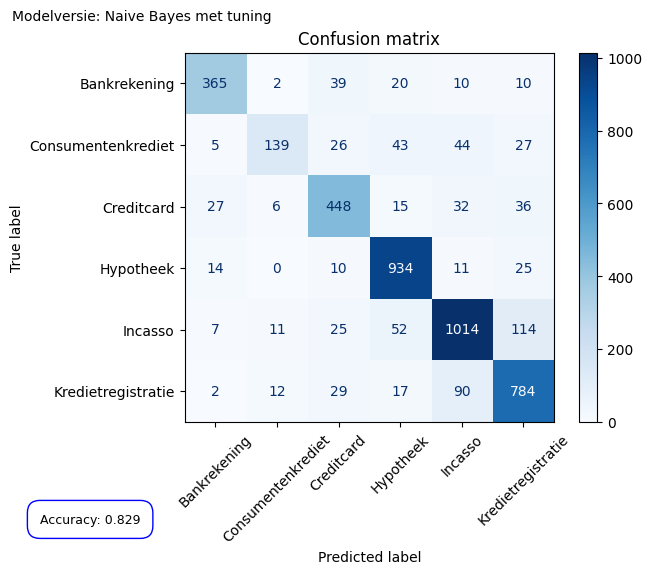

In [27]:

cm = confusion_matrix(y_test, y_pred_nb)
print(cm)

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_nb,
    cmap='Blues'
)
plt.xticks(rotation=45)
plt.title('Confusion matrix')
plt.suptitle("Modelversie: Naive Bayes met tuning", fontsize=10, x=0.1, y=0.97) # ! naam aanpassen per modelversie
plt.figtext(0.02, -0.1, f"Accuracy: {accuracy_nb:.3f}", ha='center', fontsize=9, color='black', bbox=dict(facecolor='none', edgecolor='blue', boxstyle='round,pad=1'))
plt.savefig("afbeeldingen/confusion_matrix_naive_bayes_met_tuning.png", dpi=300, bbox_inches='tight') # ! naam aanpassen per modelversie
plt.show()

#### 4.6.5 AUC-score (multiclass)

In [28]:
auc_nb = roc_auc_score(y_test, y_proba_nb, multi_class='ovr')
print(f"AUC: {auc_nb:.3f}")

AUC: 0.963


#### 4.6.6 ROC curves per productsector

In [29]:
print("Klassen:", best_nb['model'].classes_) # dit zijn alle productsectoren in het model 4

Klassen: ['Bankrekening' 'Consumentenkrediet' 'Creditcard' 'Hypotheek' 'Incasso'
 'Kredietregistratie']


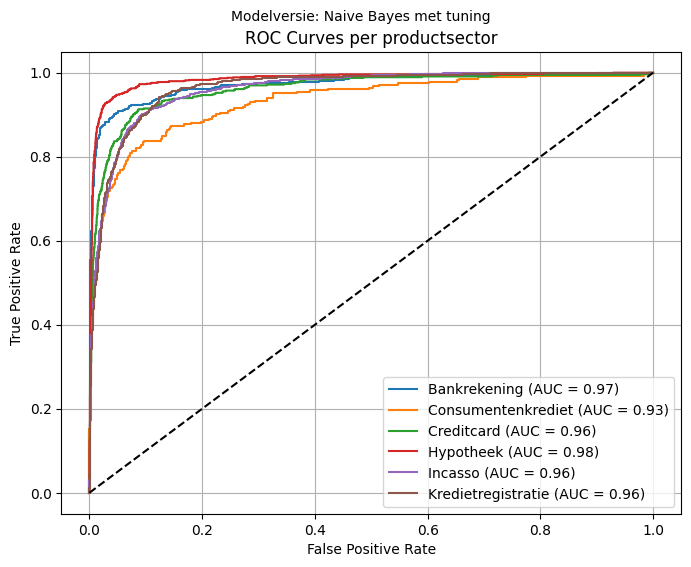

In [30]:
classes = best_nb['model'].classes_ # krijg de klassen(productsectoren) uit het model
plt.figure(figsize=(8,6))

for i in range(len(classes)): # loop over elke productsector
    class_name = classes[i]
    y_binary = (y_test == class_name).astype(int) # binaire labels voor de huidige produyctsector
    proba = y_proba_nb[:, i] # waarschijnlijkheden voor de huidige productsector
    fpr, tpr, _ = roc_curve(y_binary, proba) # bereken FPR en TPR 
    auc_score = roc_auc_score(y_binary, proba) # bereken AUC 

    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {auc_score:.2f})')

plt.plot([0,1], [0,1], '--', color='black')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves per productsector')
plt.suptitle("Modelversie: Naive Bayes met tuning", fontsize=10, y=0.95) # ! naam aanpassen per modelversie
plt.legend()
plt.grid(True)
plt.savefig("afbeeldingen/naive_bayes_roc_curves_met_tuning.png", dpi=300, bbox_inches='tight') # ! naam aanpassen per modelversie
plt.show()